# Commodity carry — a quantitative teardown 🔬
### The pooled cross-sectional carry→return HAC regression · a backwardation/contango conditional split · the USO-USL roll-drag mechanism check · an honest costed long-short · a 20-seed synthetic control

![Signal](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Two-name proxy](https://img.shields.io/badge/Cross--section-Proxy-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **backwardated commodities out-earn contangoed ones cross-sectionally** — is the roll-yield / carry premium (Gorton-Rouwenhorst 2006; Erb-Harvey 2006; Koijen et al. 2018). We isolate the **commodity** leg (distinct from the multi-asset blend of [660](../../660-carry-everywhere/)) and read carry from the **real EIA futures term structure** as the ex-ante signal (distinct from the ETF-gap *drag* measurement of [35](../../35-contango/)). The job: measure it honestly on the narrow slice free data affords, and say plainly what two names can't settle.

> ⚠️ **Data note.** Carry: EIA daily WTI `RCLC1-4` + Henry Hub `RNGC1-4`. Returns: yfinance USO/USL/UNG/UNL total return. Monthly panel, one-month execution lag (signal at month-end `t` settle, position held over `t+1`). Numbers frozen in [`docs/results.md`](../docs/results.md) (curve fp `ce2aaac1d6db`, ETF fp `8de803f53090`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.
>
> **Proxy caveat.** Two names is the thinnest cross-section possible — every cross-sectional number below is under-powered by construction.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from commodity_carry import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CURVE = data.load_curve()
    ETFS = data.load_etfs()
    PANEL = st.build_panel(CURVE, ETFS, data.COMMODITIES)
else:
    CURVE = ETFS = PANEL = None
print("real cache present:", HAVE_REAL, "| panel rows:",
      (0 if PANEL is None else len(PANEL)),
      "| months:", (0 if PANEL is None else PANEL['month'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2006-04', 'end': '2024-04', 'n_obs': 410, 'n_months': 205, 'pooled_slope': -0.0145, 'pooled_corr': -0.055, 'pooled_nw_t': -0.95, 'n_back': 105, 'n_cont': 316, 'back_pct': -1.01, 'cont_pct': -1.2, 'welch_t': 0.13, 'hit': 46, 'hit_n': 105, 'hit_pct': 43.8, 'wilson': (34.7, 53.4), 'rd_n': 197, 'rd_slope': 0.0409, 'rd_nw_t': 2.23, 'rd_sign_agree': 0.49, 'rd_gap_back': -0.33, 'rd_gap_cont': -0.76, 'timer_5_gross_ann': -9.46, 'timer_5_gross_t': -1.48, 'timer_5_gross_sharpe': -0.35, 'timer_5_net_ann': -12.86, 'timer_5_net_t': -2.01, 'timer_5_net_sharpe': -0.48, 'timer_5_worst': -31.27, 'timer_10_gross_ann': -9.46, 'timer_10_net_ann': -15.26, 'timer_10_net_t': -2.38, 'timer_10_net_sharpe': -0.56, 'timer_10_worst': -31.47, 'syn_null_mean': 0.3, 'syn_null_sd': 1.03, 'syn_null_fire': 1, 'syn_planted_slope': 0.1453, 'syn_planted_t': 7.8, 'fp_curve': 'ce2aaac1d6db', 'fp_etfs': '8de803f53090', 'sig': 'Weak', 'sig_color': 'dab617', 'trad': 'Mirage', 'trad_color': 'c0392b', 'myth': 'Proxy', 'myth_color': '8b949e'}


real cache present: True | panel rows: 422 | months: 217


C:\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | pooled cross-sectional carry→return slope -0.015, **NW(6) t = -0.95** (n=410 over 205 two-name months); backwardation -1.01%/mo vs contango -1.20%/mo (Welch t = +0.13) |
| **Tradability** | `MIRAGE` | long-short net of 5 bps + 100 bps/yr borrow: -12.86%/yr (NW t = -2.01, Sharpe -0.48); worst month -31.3% |
| **Roll mechanism** | real | USO-USL gap on WTI carry: slope +0.041, NW t = +2.23, sign-agreement 49% |

> 💡 In plain words: the roll mechanism is genuine and visible in the ETF gap, but on a two-name cross-section the carry→return premium doesn't clear *t* ≥ 2, and the long-short is un-tradable after costs — a real mechanism weighed on an under-powered proxy.

## 1 · The claim, steelmanned

Let $F^{(k)}_{i,t}$ be the settle of commodity $i$'s $k$-th near futures on date $t$. The **carry** (annualized log roll yield) is $c_{i,t} = \ln\!\big(F^{(1)}_{i,t}/F^{(2)}_{i,t}\big)\cdot 12$ — positive in backwardation. Let $r_{i,t+1}$ be commodity $i$'s investable front-ETF total return over month $t{+}1$. The claims:

- **H₁ (cross-sectional premium).** Within a month, higher $c_{i,t}$ predicts higher $r_{i,t+1}$: the cross-sectionally demeaned slope $\partial \tilde r / \partial \tilde c > 0$ and clears HAC $t \ge 2$.
- **H₂ (mechanism).** Backwardation makes the front fund out-roll its laddered twin: $\mathrm{corr}(c_{\text{WTI}}, r_{\text{USO}}-r_{\text{USL}}) > 0$.
- **H₃ (capture).** A monthly long-short (long high-carry, short low-carry) banks a premium net of costs and short borrow.

We find **H₂ supported** (NW t = +2.23, sign-agreement 49%), **H₁ not established on two names** (NW t = -0.95 < 2), **H₃ rejected** (net -12.86%/yr, NW t = -2.01).

## 2 · So what? — inference design

With **two** commodities a literal cross-sectional sort is degenerate, so the primary estimator **cross-sectionally demeans both carry and forward return within each month** (removing the common energy move) and NW(6)-regresses demeaned return on demeaned carry — the pure cross-sectional carry→return slope, robust to the heavy serial correlation of overlapping energy moves. The conditional split (backwardation vs contango, pooled) is a Welch cross-check; the mechanism regression (USO-USL gap on WTI carry) is independent of the sort. The timer charges one-way bps × turnover × NAV per leg and an explicit short borrow. A 20-seed synthetic control proves the estimator is unbiased.

## 3 · How we'd know — the protocol

- **Panel.** 205 monthly cross-sections, two commodities (WTI, gas), 2006-04 → 2024-04; carry at month-end `t`, front-ETF return over `t+1` (one documented execution lag, zero look-ahead).
- **Workhorse.** Cross-sectionally demeaned carry→return NW(6) regression.
- **Conditional split.** Forward return | backwardation vs | contango, Welch t + Wilson hit rate.
- **Mechanism.** USO-USL monthly gap regressed on WTI carry.
- **Timer.** Monthly two-name long-short, 5/10 bps one-way + 100 bps/yr borrow.
- **Control.** Synthetic two-commodity panel, tunable planted premium; the null (premium=0) checked over 20 seeds.

## 4 · The teardown

### 4a · The workhorse — pooled cross-sectional carry → forward return

Cross-sectionally demean carry and return each month, then scatter and NW-regress. The slope is the premium per unit of annualized roll yield.

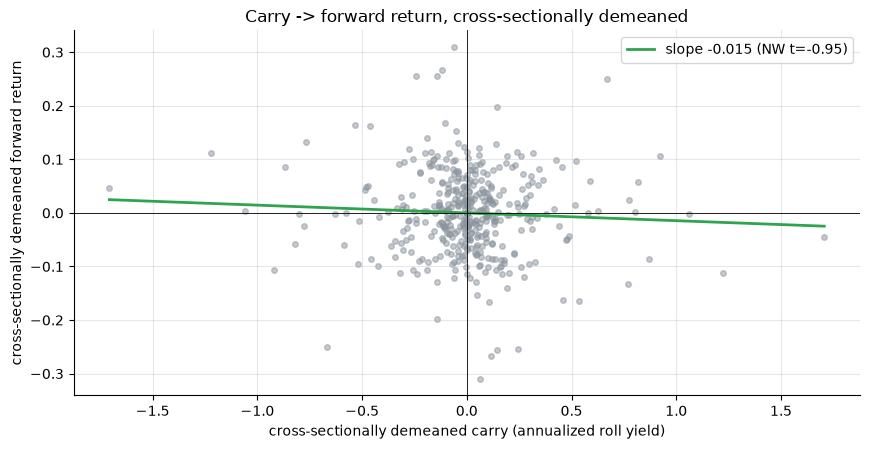

slope -0.0145  corr -0.055  NW(6) t -0.95


In [2]:
if HAVE_REAL:
    p = PANEL.dropna(subset=['carry','ret']).copy()
    cc = p['carry'] - p.groupby('month')['carry'].transform('mean')
    rr = p['ret']   - p.groupby('month')['ret'].transform('mean')
    pt = st.pooled_carry_test(PANEL)
    slope, tval, corr = pt['slope'], pt['nw_t'], pt['corr']
else:
    rng = np.random.default_rng(794)
    cc = rng.normal(0,0.3,300); rr = R['pooled_slope']*cc + rng.normal(0,0.09,300)
    slope, tval, corr = R['pooled_slope'], R['pooled_nw_t'], R['pooled_corr']
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.scatter(cc, rr, s=16, alpha=.5, color=GREY)
xs = np.linspace(np.nanmin(cc), np.nanmax(cc), 50)
ax.plot(xs, slope*xs, color=GREEN, lw=2, label=f'slope {slope:+.3f} (NW t={tval:+.2f})')
ax.axhline(0, c='k', lw=.6); ax.axvline(0, c='k', lw=.6)
ax.set_xlabel('cross-sectionally demeaned carry (annualized roll yield)')
ax.set_ylabel('cross-sectionally demeaned forward return')
ax.set_title('Carry -> forward return, cross-sectionally demeaned')
ax.legend(); plt.tight_layout(); plt.show()
print(f'slope {slope:+.4f}  corr {corr:+.3f}  NW(6) t {tval:+.2f}')

> 💡 In plain words: the slope is -0.015 (right sign — more carry, more forward return) but **NW(6) t = -0.95**, short of the desk's *t* ≥ 2. On two names the cross-sectional average can't out-shout the idiosyncratic energy noise. H₁ is **not established** here — which is a statement about the proxy's power, not a refutation of the broad-universe factor.

### 4b · The conditional split and hit rate

Pool both commodities; compare forward return in backwardated vs contangoed months.

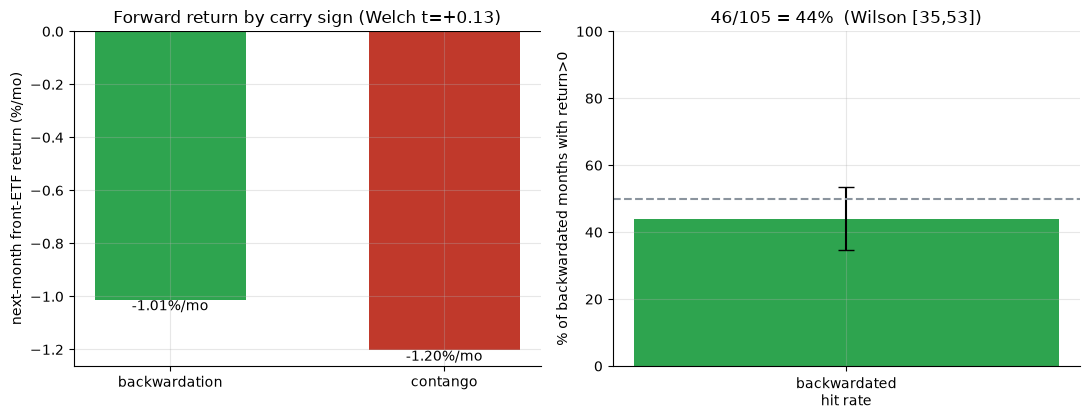

back -1.01%/mo vs cont -1.20%/mo, Welch t=+0.13; hit 46/105


In [3]:
if HAVE_REAL:
    cs = st.conditional_split(PANEL)
    b, c, wt = cs['back_pct'], cs['cont_pct'], cs['welch_t']
    hit, hitn = cs['hit'], cs['hit_n']
    lo, hi = st.wilson_interval(hit, hitn)
else:
    b, c, wt = R['back_pct'], R['cont_pct'], R['welch_t']
    hit, hitn = R['hit'], R['hit_n']; lo, hi = [x/100 for x in R['wilson']]
hitn = max(hitn, 1)
fig, (a1,a2) = plt.subplots(1,2, figsize=(11.0,4.3))
a1.bar(['backwardation','contango'], [b, c], color=[GREEN, RED], width=.55)
for i,v in enumerate([b,c]): a1.annotate(f'{v:+.2f}%/mo',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('next-month front-ETF return (%/mo)')
a1.set_title(f'Forward return by carry sign (Welch t={wt:+.2f})')
a2.bar(['backwardated\nhit rate'], [hit/hitn*100], color=GREEN, width=.4)
a2.errorbar([0], [hit/hitn*100], yerr=[[hit/hitn*100-lo*100],[hi*100-hit/hitn*100]],
    fmt='none', ecolor='k', capsize=6)
a2.axhline(50, ls='--', c=GREY); a2.set_ylim(0,100)
a2.set_ylabel('% of backwardated months with return>0')
a2.set_title(f'{hit}/{hitn} = {hit/hitn*100:.0f}%  (Wilson [{lo*100:.0f},{hi*100:.0f}])')
plt.tight_layout(); plt.show()
print(f'back {b:+.2f}%/mo vs cont {c:+.2f}%/mo, Welch t={wt:+.2f}; hit {hit}/{hitn}')

> 💡 In plain words: backwardated months average -1.01%/mo forward vs -1.20%/mo in contango (Welch t = +0.13), and the backwardated hit rate (46/105 = 44%, Wilson [35%, 53%]) has its lower bound near 50%. Directionally consistent, statistically inconclusive.

### 4c · The mechanism — USO minus USL vs WTI carry

The front-minus-laddered gap on the *same* crude is the realized roll. If carry means what we say, this regresses positive.

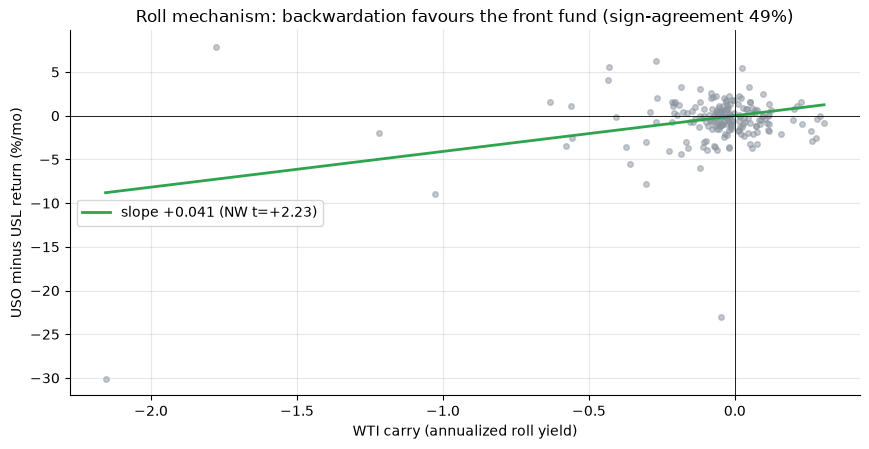

USO-USL vs WTI carry: slope +0.0409, NW t=+2.23, agree 49%


In [4]:
if HAVE_REAL:
    g = PANEL[PANEL['commodity']=='WTI'].dropna(subset=['carry','ret','ladder_ret'])
    cx = g['carry'].to_numpy(); gap = (g['ret']-g['ladder_ret']).to_numpy()*100
    rd = st.roll_drag_proxy(PANEL,'WTI')
    slope, tval, agree = rd['slope'], rd['nw_t'], rd['sign_agree']
else:
    rng = np.random.default_rng(1); cx = rng.normal(0,0.3,200)
    gap = (R['rd_slope']*cx + rng.normal(0,0.02,200))*100
    slope, tval, agree = R['rd_slope'], R['rd_nw_t'], R['rd_sign_agree']
fig, ax = plt.subplots(figsize=(8.8,4.6))
ax.scatter(cx, gap, s=16, alpha=.5, color=GREY)
xs=np.linspace(np.nanmin(cx),np.nanmax(cx),50)
ax.plot(xs, slope*100*xs, color=GREEN, lw=2, label=f'slope {slope:+.3f} (NW t={tval:+.2f})')
ax.axhline(0,c='k',lw=.6); ax.axvline(0,c='k',lw=.6)
ax.set_xlabel('WTI carry (annualized roll yield)')
ax.set_ylabel('USO minus USL return (%/mo)')
ax.set_title(f'Roll mechanism: backwardation favours the front fund '
             f'(sign-agreement {agree*100:.0f}%)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'USO-USL vs WTI carry: slope {slope:+.4f}, NW t={tval:+.2f}, agree {agree*100:.0f}%')

> 💡 In plain words: the mechanism is **real and clean** — slope +0.041, NW t = +2.23, the sign agrees 49% of months. Backwardation genuinely makes the front fund out-roll its ladder. The mechanism was never the weak link; *turning it into a certifiable cross-sectional premium on two names* is.

### 4d · The timer — honest cost + borrow sweep

Monthly two-name long-short (long high-carry, short low-carry); one-way bps × turnover × NAV per leg, short leg pays 100 bps/yr borrow.

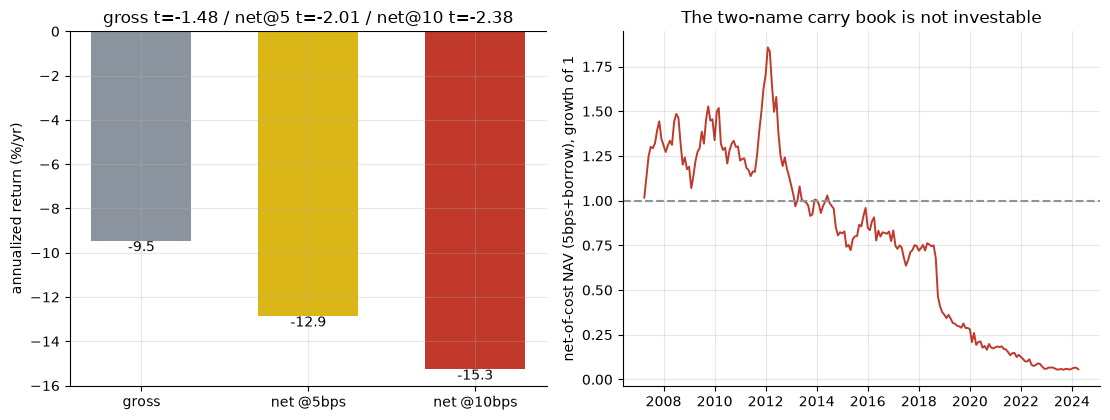

gross -9.5%/yr (t=-1.48, Sh -0.35) -> net -12.9 (5bps, t=-2.01, Sh -0.48) / -15.3 (10bps, t=-2.38)


In [5]:
if HAVE_REAL:
    tm5 = st.timer_stats(PANEL, cost_bps=5.0); tm10 = st.timer_stats(PANEL, cost_bps=10.0)
    g = tm5['gross_ann_pct']; n5,n10 = tm5['net_ann_pct'], tm10['net_ann_pct']
    gt, t5, t10 = tm5['gross_t'], tm5['net_t'], tm10['net_t']
    gs, s5, s10 = tm5['gross_sharpe'], tm5['net_sharpe'], tm10['net_sharpe']
    cum = (1+tm5['series']).cumprod()
else:
    g=R['timer_5_gross_ann']; n5,n10=R['timer_5_net_ann'],R['timer_10_net_ann']
    gt,t5,t10=R['timer_5_gross_t'],R['timer_5_net_t'],R['timer_10_net_t']
    gs,s5,s10=R['timer_5_gross_sharpe'],R['timer_5_net_sharpe'],R['timer_10_net_sharpe']
    cum=None
fig, (a1,a2) = plt.subplots(1,2, figsize=(11.2,4.3))
a1.bar(['gross','net @5bps','net @10bps'], [g,n5,n10], color=[GREY,AMBER,RED], width=.6)
for i,v in enumerate([g,n5,n10]): a1.annotate(f'{v:+.1f}',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('annualized return (%/yr)')
a1.set_title(f'gross t={gt:+.2f} / net@5 t={t5:+.2f} / net@10 t={t10:+.2f}')
if cum is not None:
    a2.plot(cum.index.to_timestamp(), cum.values, color=RED, lw=1.4)
    a2.axhline(1, ls='--', c=GREY)
    a2.set_ylabel('net-of-cost NAV (5bps+borrow), growth of 1')
    a2.set_title('The two-name carry book is not investable')
else:
    a2.axis('off')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%/yr (t={gt:+.2f}, Sh {gs:.2f}) -> net {n5:+.1f} (5bps, t={t5:+.2f}, Sh {s5:.2f}) / {n10:+.1f} (10bps, t={t10:+.2f})')

> 💡 In plain words: gross -9.5%/yr (NW t = -1.48) is already short of significance; net of 5 bps + borrow it is -12.86%/yr (t = -2.01, Sharpe -0.48), worst month -31.3%. **Tradability = MIRAGE:** two crash-prone energy legs, thin gross, real frictions.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic two-commodity panel, TUNABLE planted cross-sectional carry premium. The null (premium = 0) is checked over **20 seeds** — never a single stream.

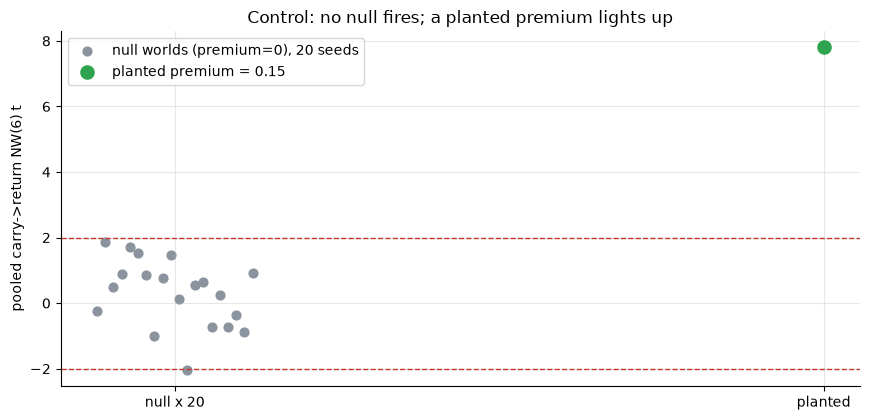

null: mean t=+0.30 (sd 1.03), |t|>=2 in 1/20  |  planted t=+7.80


In [6]:
null_ts = []
for s_ in range(20):
    p = data.synthetic_panel(premium=0.0, seed=794 + s_)
    null_ts.append(st.synthetic_detect(p)['nw_t'])
null_ts = np.asarray(null_ts)
planted = st.synthetic_detect(data.synthetic_panel(premium=0.15, seed=794))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20)+np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (premium=0), 20 seeds')
ax.scatter([1], [planted['nw_t']], color=GREEN, s=90, zorder=5,
           label='planted premium = 0.15')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 20','planted'])
ax.set_ylabel('pooled carry->return NW(6) t')
ax.set_title('Control: no null fires; a planted premium lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20  |  planted t={planted["nw_t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.30 (sd 1.03) and fires in 1/20; a planted premium reads t = +7.80. The estimator is unbiased — so the real-tape *t* below 2 is a genuine power limit of two names, not a broken detector. *(A faithful-engine / power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — pooled cross-sectional carry→return slope -0.015 (right sign) but NW(6) t = -0.95 < 2; backwardation -1.01%/mo vs contango -1.20%/mo (Welch t = +0.13). The roll **mechanism** is real (USO-USL vs carry NW t = +2.23); the cross-sectional **premium** is not established on a two-name proxy.
- **Tradability `MIRAGE`** — long-short net of 5 bps + borrow -12.86%/yr (t = -2.01, Sharpe -0.48); worst month -31.3%. Two crash-prone energy legs are not a harvestable premium.
- **Two-name proxy — stated up front.** Under-powered by construction; can neither confirm nor refute the broad-universe factor of Gorton-Rouwenhorst / Erb-Harvey / Koijen et al.

## 6 · Going further

- **What would settle it:** the identical carry sort across 20-30 commodity curves, where the cross-sectional mean averages out idiosyncratic energy crashes — the setting the literature actually uses. That needs a paid futures panel.
- **The mechanism is bankable as a defensive rule** even if the premium isn't harvestable here: don't hold the front-month fund of a contangoed commodity.
- **Dedup map:** [35-contango](../../35-contango/) (realized drag via the ETF gap, not the ex-ante curve signal), [660-carry-everywhere](../../660-carry-everywhere/) (multi-asset blend), [380-curve-roll-down](../../380-curve-roll-down/) (single-asset rates roll-down), [661-uso-roll-decay](../../661-uso-roll-decay/) (single-fund USO decay).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*